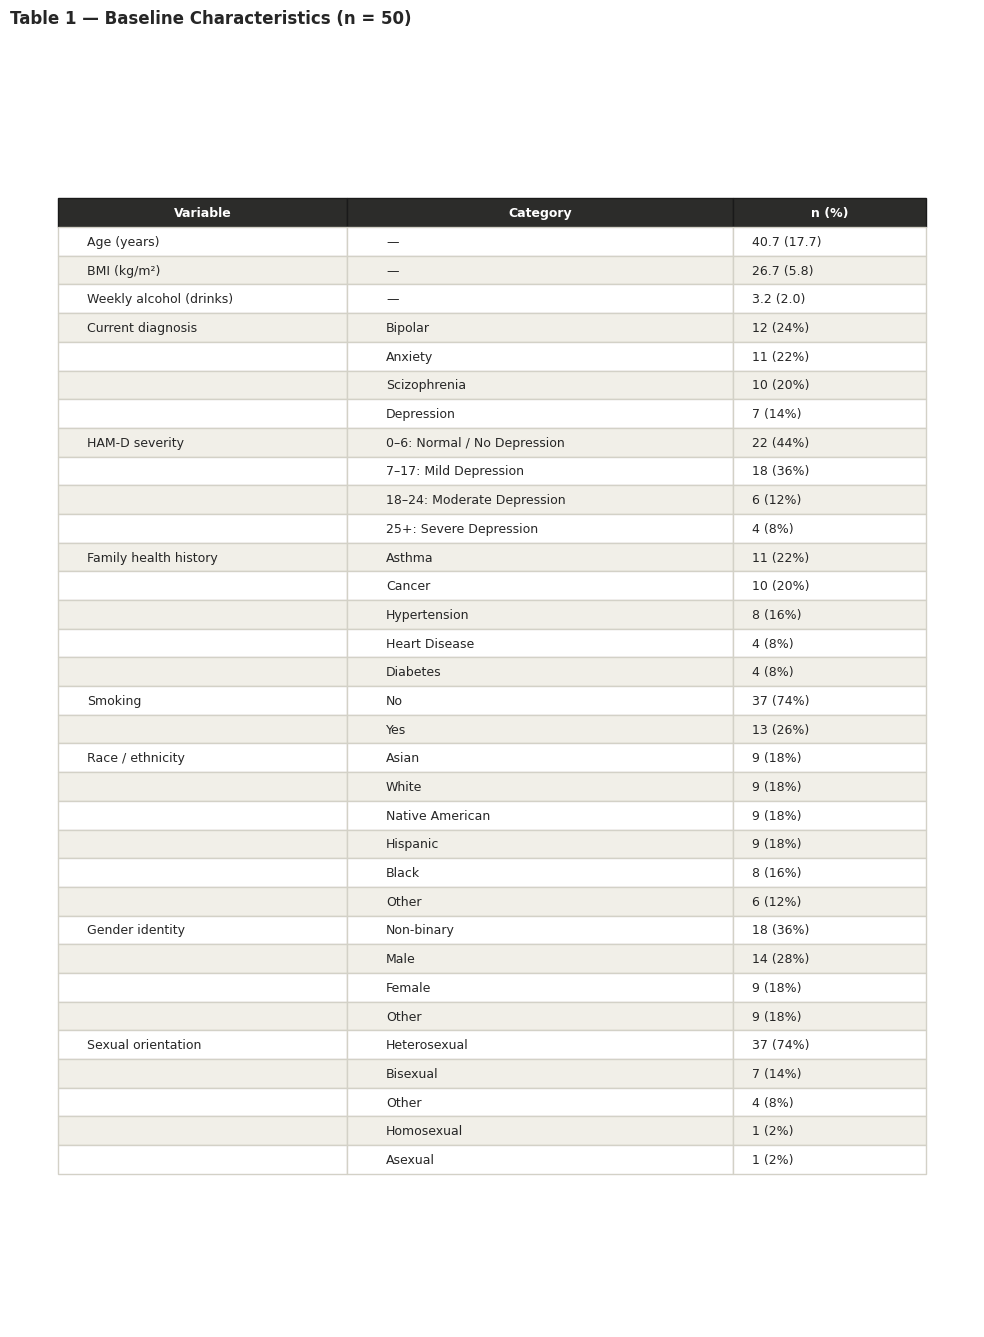

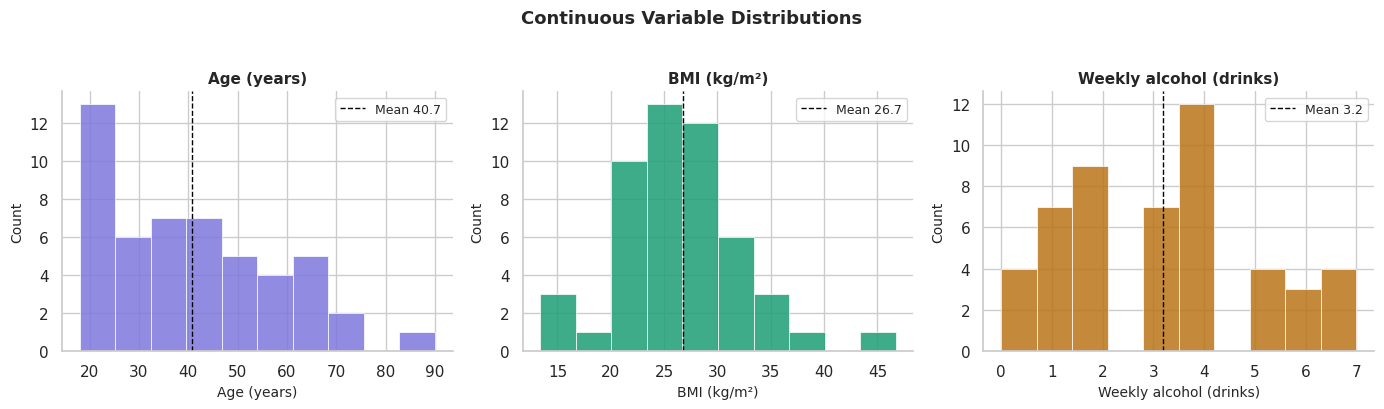

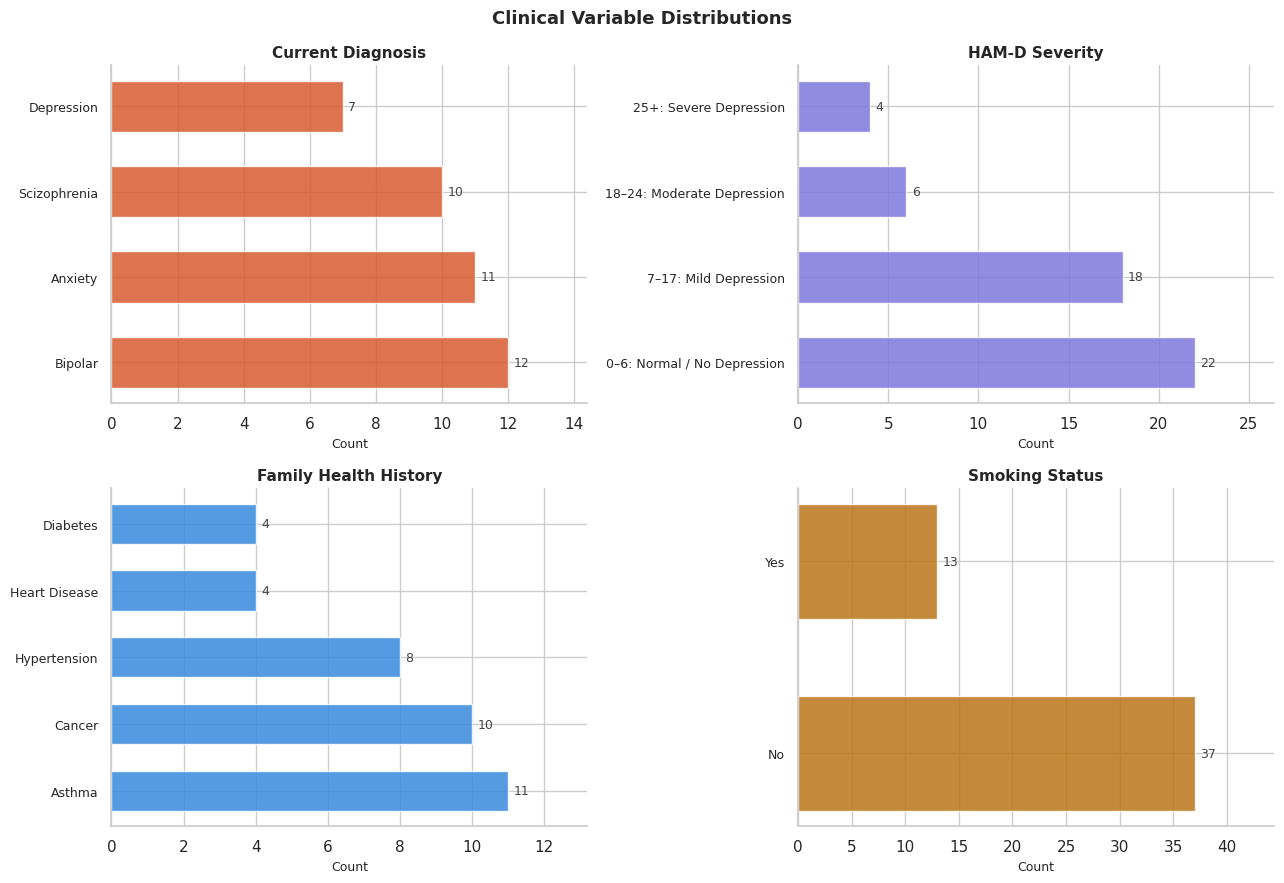

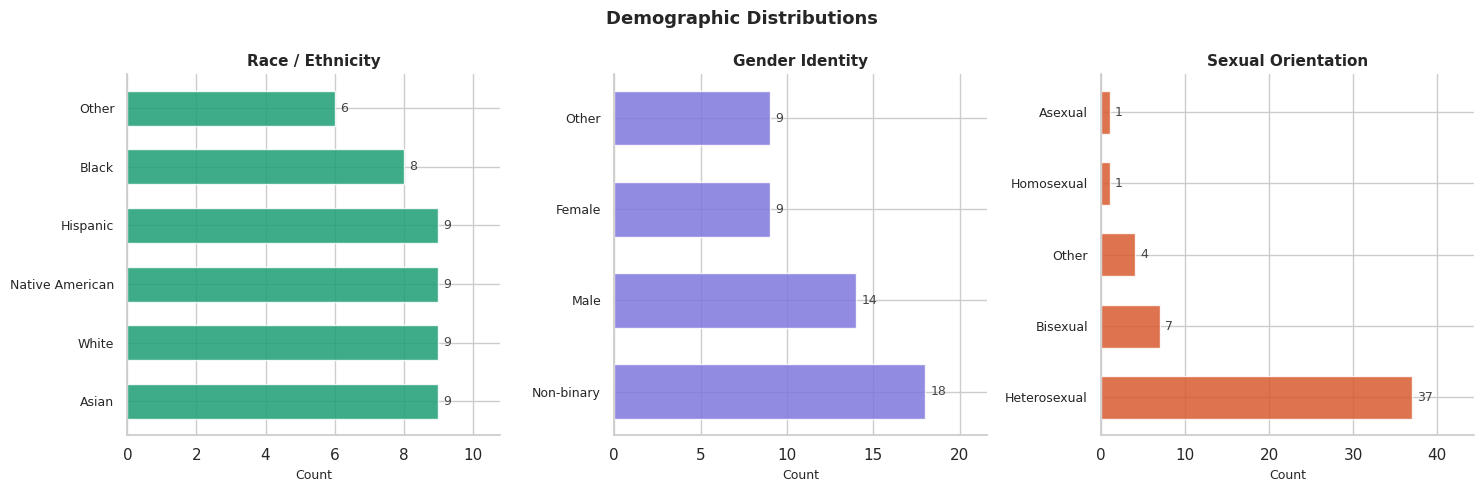

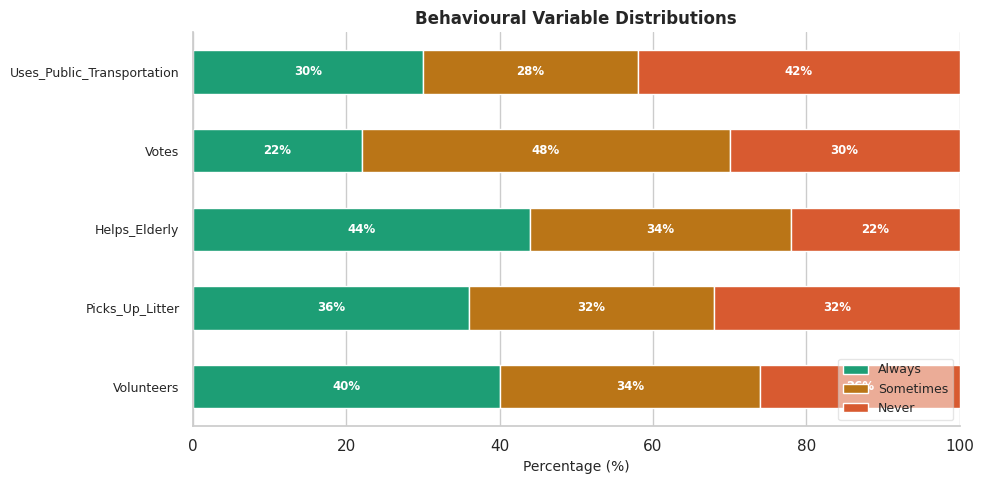

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import to_rgba

df = pd.read_csv("synthetic_data1.csv")

# ── Palette ────────────────────────────────────────────────────────────────────
PURPLE = "#7F77DD"
TEAL   = "#1D9E75"
CORAL  = "#D85A30"
BLUE   = "#378ADD"
AMBER  = "#BA7517"

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})


# ── 1. TABLE 1 ─────────────────────────────────────────────────────────────────
# Continuous: mean (SD), median, range
cont_vars = {"Age": "Age (years)", "BMI": "BMI (kg/m²)", "Weekly_Alcohol_Intake": "Weekly alcohol (drinks)"}

rows = []
for col, label in cont_vars.items():
    s = df[col]
    rows.append({
        "Variable": label,
        "Category": "—",
        "n (%)": f"{s.mean():.1f} ({s.std():.1f})",
        "Stat": "Mean (SD)"
    })

# Categorical: n (%)
cat_vars = {
    "Current_Diagnosis":   "Current diagnosis",
    "HAM-D":               "HAM-D severity",
    "Family_Health_History": "Family health history",
    "Smoking":             "Smoking",
    "Race":                "Race / ethnicity",
    "Gender":              "Gender identity",
    "Sexual_Orientation":  "Sexual orientation",
}

for col, label in cat_vars.items():
    vc = df[col].value_counts()
    for i, (cat, n) in enumerate(vc.items()):
        rows.append({
            "Variable": label if i == 0 else "",
            "Category": cat,
            "n (%)": f"{n} ({100*n/len(df):.0f}%)",
            "Stat": ""
        })

table1 = pd.DataFrame(rows)[["Variable", "Category", "n (%)"]]

# Render as a matplotlib table (presentation-ready)
fig, ax = plt.subplots(figsize=(10, len(table1) * 0.38 + 1))
ax.axis("off")
tbl = ax.table(
    cellText=table1.values,
    colLabels=table1.columns,
    cellLoc="left",
    loc="center",
    colWidths=[0.3, 0.4, 0.2],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)

# Style header
for j in range(len(table1.columns)):
    tbl[0, j].set_facecolor("#2C2C2A")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

# Alternating row shading
for i in range(1, len(table1) + 1):
    color = "#F1EFE8" if i % 2 == 0 else "white"
    for j in range(len(table1.columns)):
        tbl[i, j].set_facecolor(color)
        tbl[i, j].set_edgecolor("#D3D1C7")

plt.title("Table 1 — Baseline Characteristics (n = 50)",
          fontsize=12, fontweight="bold", pad=16, loc="left")
plt.tight_layout()
plt.savefig("table1.png", dpi=200, bbox_inches="tight")
plt.show()


# ── 2. CONTINUOUS DISTRIBUTIONS ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (col, label, color) in zip(axes, [
    ("Age",                  "Age (years)",           PURPLE),
    ("BMI",                  "BMI (kg/m²)",           TEAL),
    ("Weekly_Alcohol_Intake","Weekly alcohol (drinks)",AMBER),
]):
    sns.histplot(df[col], bins=10, color=color, alpha=0.85, ax=ax, edgecolor="white", linewidth=0.5)
    ax.axvline(df[col].mean(), color="black", linestyle="--", linewidth=1, label=f"Mean {df[col].mean():.1f}")
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.legend(fontsize=9)
    ax.set_title(label, fontsize=11, fontweight="bold")

plt.suptitle("Continuous Variable Distributions", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("continuous_distributions.png", dpi=200, bbox_inches="tight")
plt.show()


# ── 3. CLINICAL CATEGORICALS ───────────────────────────────────────────────────
clinical_cats = {
    "Current_Diagnosis":     ("Current Diagnosis",     CORAL),
    "HAM-D":                 ("HAM-D Severity",        PURPLE),
    "Family_Health_History": ("Family Health History", BLUE),
    "Smoking":               ("Smoking Status",        AMBER),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (col, (label, color)) in zip(axes.flat, clinical_cats.items()):
    vc = df[col].value_counts()
    bars = ax.barh(vc.index, vc.values, color=color, alpha=0.85, edgecolor="white", height=0.6)
    ax.bar_label(bars, fmt="%d", padding=4, fontsize=9, color="#444")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Count", fontsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.set_xlim(0, vc.max() * 1.2)

plt.suptitle("Clinical Variable Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("clinical_distributions.png", dpi=200, bbox_inches="tight")
plt.show()


# ── 4. DEMOGRAPHIC CATEGORICALS ────────────────────────────────────────────────
demo_cats = {
    "Race":               ("Race / Ethnicity",    TEAL),
    "Gender":             ("Gender Identity",     PURPLE),
    "Sexual_Orientation": ("Sexual Orientation",  CORAL),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (col, (label, color)) in zip(axes, demo_cats.items()):
    vc = df[col].value_counts()
    bars = ax.barh(vc.index, vc.values, color=color, alpha=0.85, edgecolor="white", height=0.6)
    ax.bar_label(bars, fmt="%d", padding=4, fontsize=9, color="#444")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Count", fontsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.set_xlim(0, vc.max() * 1.2)

plt.suptitle("Demographic Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("demographic_distributions.png", dpi=200, bbox_inches="tight")
plt.show()


# ── 5. BEHAVIOURAL VARIABLES (stacked bar) ─────────────────────────────────────
behav_vars = ["Volunteers", "Picks_Up_Litter", "Helps_Elderly",
              "Votes", "Uses_Public_Transportation"]

order = ["Always", "Sometimes", "Never"]
behav_colors = [TEAL, AMBER, CORAL]

behav_df = pd.DataFrame({
    var: df[var].value_counts(normalize=True).reindex(order, fill_value=0) * 100
    for var in behav_vars
}).T

fig, ax = plt.subplots(figsize=(10, 5))
bottom = pd.Series([0.0] * len(behav_df), index=behav_df.index)
for cat, color in zip(order, behav_colors):
    bars = ax.barh(behav_df.index, behav_df[cat], left=bottom,
                   color=color, label=cat, edgecolor="white", height=0.55)
    for bar, val in zip(bars, behav_df[cat]):
        if val > 8:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                    f"{val:.0f}%", ha="center", va="center", fontsize=8.5,
                    color="white", fontweight="bold")
    bottom += behav_df[cat]

ax.set_xlabel("Percentage (%)", fontsize=10)
ax.set_xlim(0, 100)
ax.legend(loc="lower right", fontsize=9, framealpha=0.5)
ax.tick_params(axis="y", labelsize=9)
ax.set_title("Behavioural Variable Distributions", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("behavioural_distributions.png", dpi=200, bbox_inches="tight")
plt.show()